In [1]:
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/mini_projet_darija'
print(f'Drive montee. Base = {BASE}')

Mounted at /content/drive
Drive montee. Base = /content/drive/MyDrive/mini_projet_darija


# 01 — Analyse Exploratoire du Corpus TWIFL

**Projet** : Gestion du desequilibre de classes pour l'analyse de sentiments en dialecte algerien

| Parametre | Valeur |
|---|---|
| Universite | USDB Blida 1 — Departement Informatique |
| Niveau | Master 1 DS & NLP — Semestre 2 |
| Module | Machine Learning |
| Enseignante | Dr. Soraya Cheriguene |
| Etudiant | Abdelaziz Merzoug |
| Date | 08 Mars 2026 |
| Semaine | 1 / 6 |
| Plateforme | Google Colab CPU |
| Notebook | 01_EDA.ipynb |

**Objectif** : Comprendre le corpus TWIFL (6 000 tweets algeriens) avant toute modelisation.  
Valider la colonne cible, quantifier le desequilibre, analyser les caracteristiques linguistiques du darija.

In [2]:
# =============================================================================
# CELL 02 — Installation des dependances et creation des repertoires
# =============================================================================
!pip install -q datasets>=2.16.0 transformers>=4.36.0 pandas>=2.1.0 numpy>=1.24.0 \
    matplotlib>=3.8.0 seaborn>=0.13.0 wordcloud>=1.9.0 emoji>=2.8.0 \
    arabic-reshaper>=3.0.0 python-bidi>=0.4.2 scikit-learn>=1.3.0 \
    imbalanced-learn>=0.11.0

import os
for d in ['figures', 'results', 'data']:
    os.makedirs(d, exist_ok=True)
print('Repertoires crees : figures/ results/ data/')

Repertoires crees : figures/ results/ data/


In [3]:
# =============================================================================
# CELL 03 — Imports + Constantes globales
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import warnings
from collections import Counter

import emoji
import arabic_reshaper
from bidi.algorithm import get_display
from wordcloud import WordCloud
from datasets import load_dataset

warnings.filterwarnings('ignore')

# --- Constantes du projet (identiques dans TOUS les notebooks) ---
TEXT_COL  = 'Post'             # Colonne texte verifiee
LABEL_COL = 'Polarity Class'   # Colonne cible verifiee
LANG_COL  = 'lang'             # Colonne langue verifiee
SEED      = 42                 # Graine aleatoire imposee par le protocole

CLASSES_ATTENDUES = {'Positive', 'Negative', 'Neutral'}

# Configuration graphique globale
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid')
np.random.seed(SEED)

print('Imports termines. Constantes definies.')
print(f'TEXT_COL={TEXT_COL!r}, LABEL_COL={LABEL_COL!r}, LANG_COL={LANG_COL!r}, SEED={SEED}')

Imports termines. Constantes definies.
TEXT_COL='Post', LABEL_COL='Polarity Class', LANG_COL='lang', SEED=42


In [4]:
# =============================================================================
# CELL 04 — Chargement du corpus TWIFL + Validation stricte de Polarity Class
# =============================================================================
# L'Enonce (par. 2) exige : "verifier l'absence de valeurs inattendues"

dataset = load_dataset('arbml/Twifil')
df = dataset['train'].to_pandas()

print('=== INFORMATIONS GENERALES ===')
print(f'Shape            : {df.shape}')
print(f'Colonnes         : {df.columns.tolist()}')
print(f'Types            :\n{df.dtypes}')
print()

# --- Validation critique de la colonne cible ---
assert LABEL_COL in df.columns, f'Colonne {LABEL_COL!r} absente du dataset'
assert TEXT_COL in df.columns, f'Colonne {TEXT_COL!r} absente du dataset'

valeurs_uniques = set(df[LABEL_COL].unique())
valeurs_manquantes = df[LABEL_COL].isna().sum()

print('=== VALIDATION POLARITY CLASS ===')
print(f'Valeurs uniques      : {valeurs_uniques}')
print(f'Valeurs attendues    : {CLASSES_ATTENDUES}')
print(f'Valeurs manquantes   : {valeurs_manquantes}')

# Verification stricte : exactement 3 classes, aucune valeur inattendue
assert valeurs_manquantes == 0, 'Valeurs manquantes detectees dans Polarity Class'
assert valeurs_uniques == CLASSES_ATTENDUES, (
    f'Valeurs inattendues : {valeurs_uniques - CLASSES_ATTENDUES}'
)
print('Validation OK : exactement 3 classes (Positive, Negative, Neutral), aucune valeur manquante.')

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001-eef2e32ea1bb4a(…):   0%|          | 0.00/699k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

=== INFORMATIONS GENERALES ===
Shape            : (6000, 16)
Colonnes         : ['ID', 'Code', 'Post', 'lang', 'Created At', 'Followers Count', 'Profile Link Color', 'Geo Enabled', 'Screen Name', 'Name', 'Profile Lang', 'Polarity', 'Polarity Class', 'User Age', 'Emotion', 'Platform']
Types            :
ID                    object
Code                  object
Post                  object
lang                  object
Created At            object
Followers Count       object
Profile Link Color    object
Geo Enabled           object
Screen Name           object
Name                  object
Profile Lang          object
Polarity              object
Polarity Class        object
User Age              object
Emotion               object
Platform              object
dtype: object

=== VALIDATION POLARITY CLASS ===
Valeurs uniques      : {'Positive', 'Negative', 'Neutral'}
Valeurs attendues    : {'Positive', 'Negative', 'Neutral'}
Valeurs manquantes   : 0
Validation OK : exactement 3 classes (Po

## Justification de l'etape de validation

L'Enonce exige explicitement de **verifier l'absence de valeurs inattendues** dans la colonne `Polarity Class`. Cette etape est cruciale car :

1. Une valeur inattendue (faute de frappe, classe supplementaire) fausserait toutes les metriques de classification.
2. Des valeurs manquantes (NaN) provoqueraient des erreurs silencieuses lors du calcul du F1-macro.
3. La validation confirme que le dataset contient exactement les 3 classes attendues (Positive, Negative, Neutral) sans anomalie.

Resultat : la colonne `Polarity Class` est **valide** — aucune correction necessaire.

In [5]:
# =============================================================================
# CELL 06 — Distribution des classes : effectifs, pourcentages, ratio
# =============================================================================
# Enonce (par. 1.1) : "Calculer le nombre d'exemples par classe"
#                      "Calculer le ratio de desequilibre"

class_counts = df[LABEL_COL].value_counts()
class_pct = df[LABEL_COL].value_counts(normalize=True) * 100

classe_majoritaire = class_counts.idxmax()
classe_minoritaire = class_counts.idxmin()
ratio_desequilibre = class_counts.max() / class_counts.min()

print('=== DISTRIBUTION DES CLASSES ===')
for cls in ['Positive', 'Negative', 'Neutral']:
    print(f'  {cls:10s} : {class_counts[cls]:5d} tweets ({class_pct[cls]:5.1f}%)')
print(f'  {"TOTAL":10s} : {len(df):5d} tweets (100.0%)')
print()
print(f'Classe majoritaire : {classe_majoritaire} ({class_counts.max()} tweets)')
print(f'Classe minoritaire : {classe_minoritaire} ({class_counts.min()} tweets)')
print(f'Ratio de desequilibre : {classe_majoritaire}/{classe_minoritaire} = {ratio_desequilibre:.2f}:1')
print()

# Classification du niveau de desequilibre (Enonce par. 1.1)
if ratio_desequilibre > 5:
    niveau = 'FORTEMENT desequilibre (> 5:1)'
elif ratio_desequilibre >= 3:
    niveau = 'MODEREMENT desequilibre (3:1 a 5:1)'
else:
    niveau = 'FAIBLEMENT desequilibre (< 3:1)'
print(f'Conclusion : corpus {niveau}')

=== DISTRIBUTION DES CLASSES ===
  Positive   :  2864 tweets ( 47.7%)
  Negative   :  1773 tweets ( 29.5%)
  Neutral    :  1363 tweets ( 22.7%)
  TOTAL      :  6000 tweets (100.0%)

Classe majoritaire : Positive (2864 tweets)
Classe minoritaire : Neutral (1363 tweets)
Ratio de desequilibre : Positive/Neutral = 2.10:1

Conclusion : corpus FAIBLEMENT desequilibre (< 3:1)


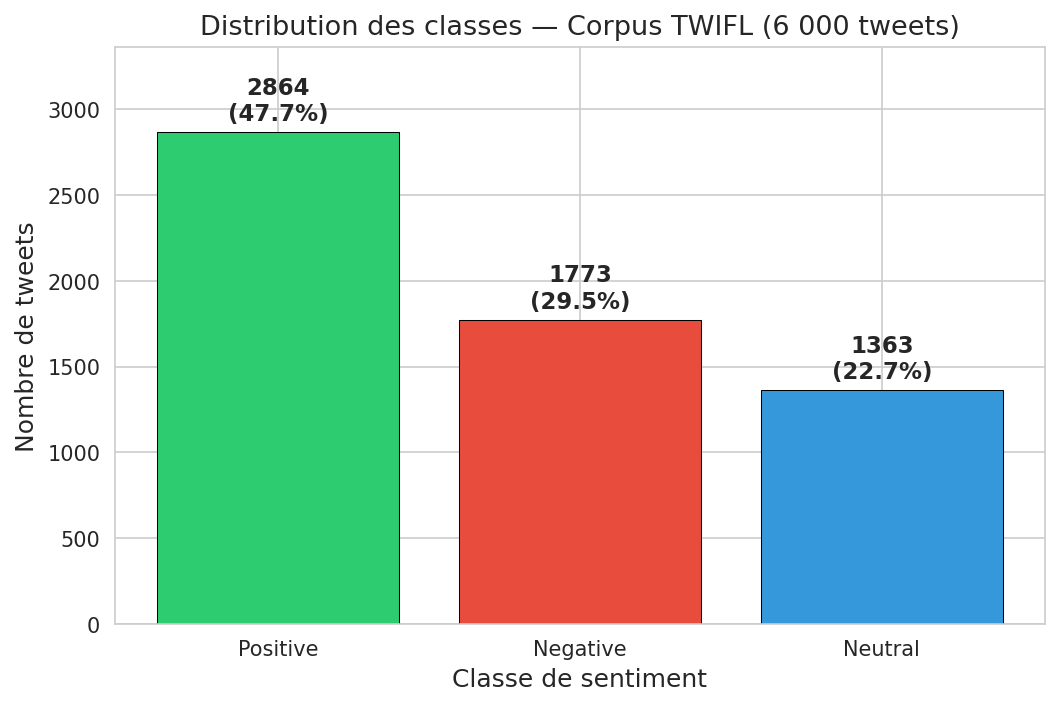

Figure sauvegardee : figures/class_distribution_bar.png


In [6]:
# =============================================================================
# CELL 07 — Bar chart de la distribution des classes
# =============================================================================
couleurs = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#3498db'}
ordre_classes = ['Positive', 'Negative', 'Neutral']

fig, ax = plt.subplots(figsize=(8, 5))
barres = ax.bar(
    ordre_classes,
    [class_counts[c] for c in ordre_classes],
    color=[couleurs[c] for c in ordre_classes],
    edgecolor='black', linewidth=0.5
)

# Annotations au-dessus de chaque barre
for barre, cls in zip(barres, ordre_classes):
    hauteur = barre.get_height()
    ax.text(
        barre.get_x() + barre.get_width() / 2, hauteur + 40,
        f'{int(hauteur)}\n({class_pct[cls]:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_xlabel('Classe de sentiment', fontsize=12)
ax.set_ylabel('Nombre de tweets', fontsize=12)
ax.set_title('Distribution des classes — Corpus TWIFL (6 000 tweets)', fontsize=13)
ax.set_ylim(0, class_counts.max() + 500)

plt.savefig('figures/class_distribution_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/class_distribution_bar.png')

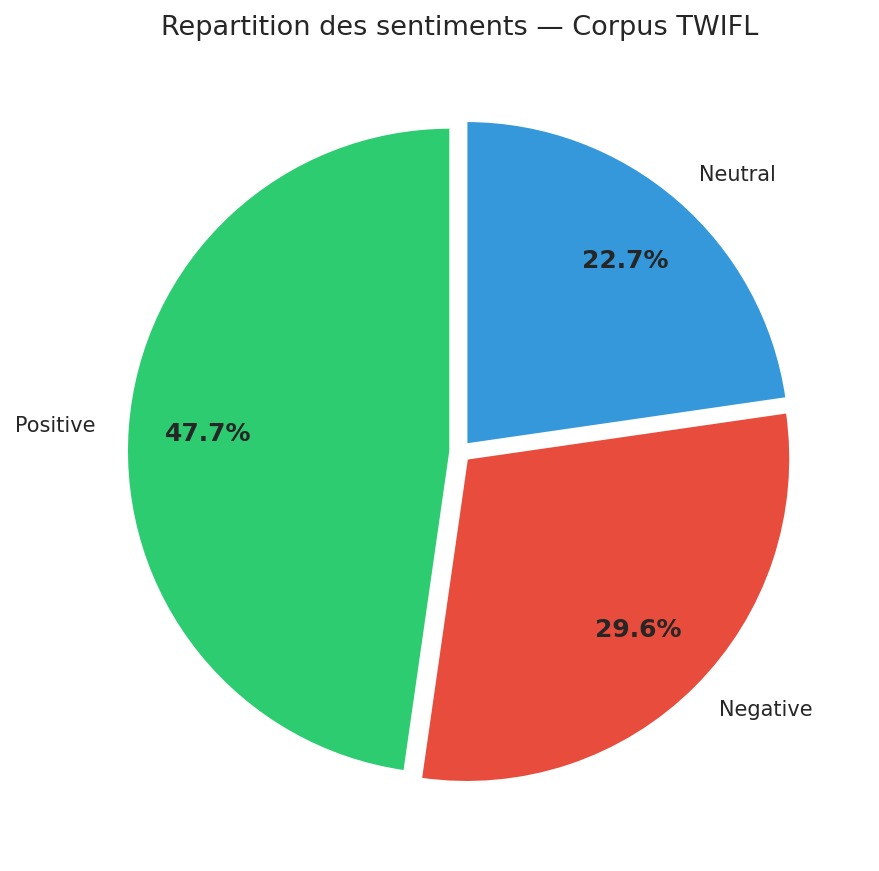

Figure sauvegardee : figures/class_distribution_pie.png


In [7]:
# =============================================================================
# CELL 08 — Pie chart de la distribution des classes
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    [class_counts[c] for c in ordre_classes],
    labels=ordre_classes,
    colors=[couleurs[c] for c in ordre_classes],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    explode=(0.03, 0.03, 0.03)
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
ax.set_title('Repartition des sentiments — Corpus TWIFL', fontsize=13)

plt.savefig('figures/class_distribution_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/class_distribution_pie.png')

## Conclusion sur le desequilibre

Le corpus TWIFL presente un desequilibre **faible a modere** avec un ratio de **2.10:1** (Positive : 2 864 vs Neutral : 1 363). Ce ratio est en dessous du seuil de 3:1 generalement considere comme moderement desequilibre.

Cependant, meme un desequilibre de 2:1 peut biaiser un modele de type BERT, qui tend naturellement a optimiser la perte globale en favorisant la classe majoritaire (Positive). Le F1-macro de la baseline devrait reflecter ce biais : on attend un F1 eleve pour la classe Positive et un F1 plus faible pour la classe Neutral (minoritaire).

Ce niveau de desequilibre justifie pleinement l'application des trois strategies de correction prevues dans le protocole experimental.

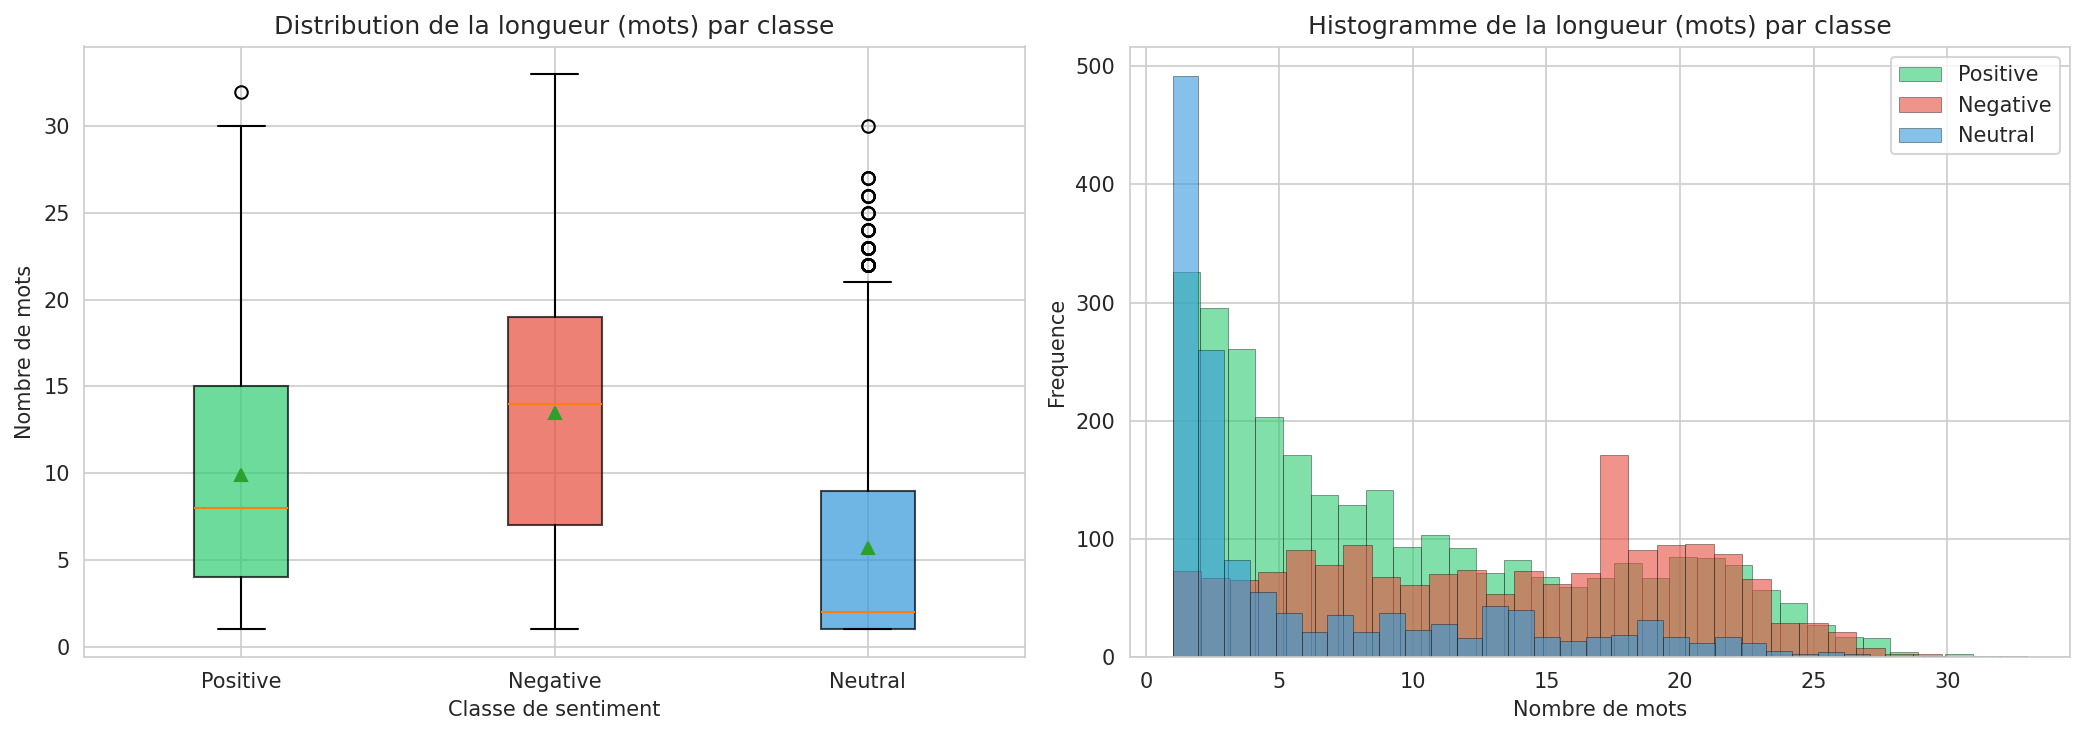

Figure sauvegardee : figures/tweet_length_words_boxplot.png

=== STATISTIQUES : LONGUEUR EN MOTS ===
  Positive   : moy=9.9, med=8, min=1, max=32
  Negative   : moy=13.5, med=14, min=1, max=33
  Neutral    : moy=5.7, med=2, min=1, max=30


In [8]:
# =============================================================================
# CELL 10 — Longueur des tweets en MOTS : boxplot + histogramme par classe
# =============================================================================
# Enonce (par. 1.2) : "Distribution de la longueur des tweets (en mots) — par classe"

df['nb_mots'] = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

# --- Boxplot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot mots par classe
data_box = [df.loc[df[LABEL_COL] == c, 'nb_mots'].values for c in ordre_classes]
bp = axes[0].boxplot(data_box, labels=ordre_classes, patch_artist=True, showmeans=True)
for patch, cls in zip(bp['boxes'], ordre_classes):
    patch.set_facecolor(couleurs[cls])
    patch.set_alpha(0.7)
axes[0].set_xlabel('Classe de sentiment')
axes[0].set_ylabel('Nombre de mots')
axes[0].set_title('Distribution de la longueur (mots) par classe')

# Histogramme mots par classe
for cls in ordre_classes:
    subset = df.loc[df[LABEL_COL] == cls, 'nb_mots']
    axes[1].hist(subset, bins=30, alpha=0.6, label=cls, color=couleurs[cls], edgecolor='black', linewidth=0.3)
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Histogramme de la longueur (mots) par classe')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/tweet_length_words_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/tweet_length_words_boxplot.png')

# Statistiques descriptives
print('\n=== STATISTIQUES : LONGUEUR EN MOTS ===')
for cls in ordre_classes:
    s = df.loc[df[LABEL_COL] == cls, 'nb_mots']
    print(f'  {cls:10s} : moy={s.mean():.1f}, med={s.median():.0f}, min={s.min()}, max={s.max()}')

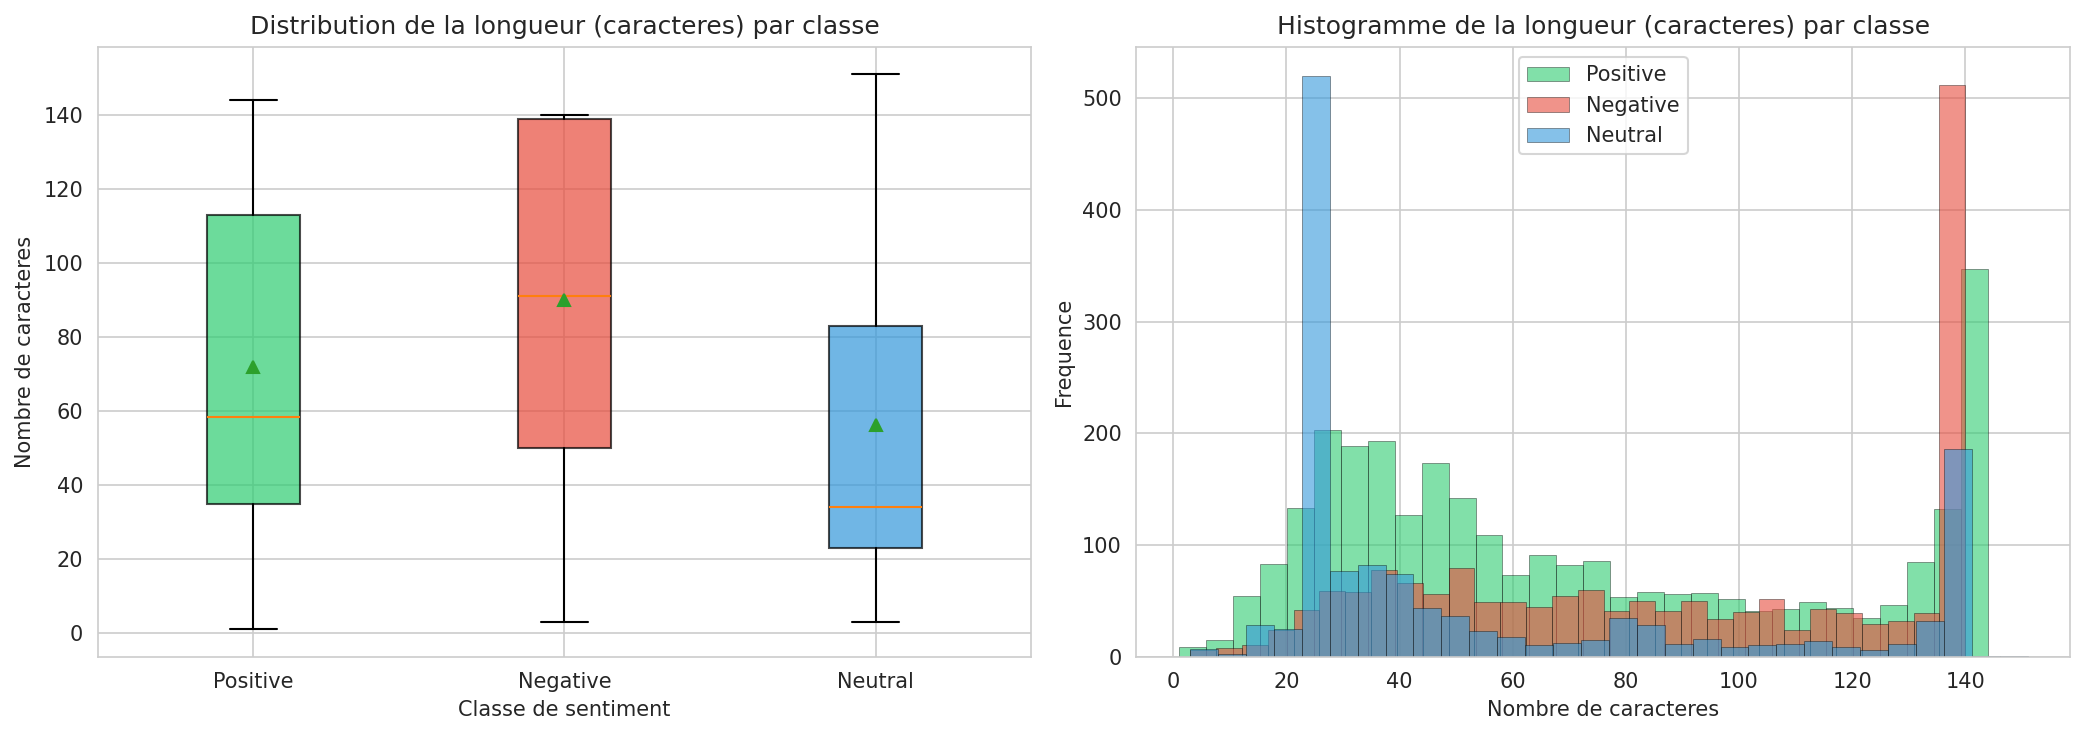

Figure sauvegardee : figures/tweet_length_chars_histogram.png

=== STATISTIQUES : LONGUEUR EN CARACTERES ===
  Positive   : moy=71.9, med=58, min=1, max=144
  Negative   : moy=90.0, med=91, min=3, max=140
  Neutral    : moy=56.3, med=34, min=3, max=151


In [9]:
# =============================================================================
# CELL 11 — Longueur des tweets en CARACTERES : boxplot + histogramme par classe
# =============================================================================
df['nb_chars'] = df[TEXT_COL].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot caracteres par classe
data_box_c = [df.loc[df[LABEL_COL] == c, 'nb_chars'].values for c in ordre_classes]
bp2 = axes[0].boxplot(data_box_c, labels=ordre_classes, patch_artist=True, showmeans=True)
for patch, cls in zip(bp2['boxes'], ordre_classes):
    patch.set_facecolor(couleurs[cls])
    patch.set_alpha(0.7)
axes[0].set_xlabel('Classe de sentiment')
axes[0].set_ylabel('Nombre de caracteres')
axes[0].set_title('Distribution de la longueur (caracteres) par classe')

# Histogramme caracteres par classe
for cls in ordre_classes:
    subset = df.loc[df[LABEL_COL] == cls, 'nb_chars']
    axes[1].hist(subset, bins=30, alpha=0.6, label=cls, color=couleurs[cls], edgecolor='black', linewidth=0.3)
axes[1].set_xlabel('Nombre de caracteres')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Histogramme de la longueur (caracteres) par classe')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/tweet_length_chars_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/tweet_length_chars_histogram.png')

# Statistiques descriptives
print('\n=== STATISTIQUES : LONGUEUR EN CARACTERES ===')
for cls in ordre_classes:
    s = df.loc[df[LABEL_COL] == cls, 'nb_chars']
    print(f'  {cls:10s} : moy={s.mean():.1f}, med={s.median():.0f}, min={s.min()}, max={s.max()}')

## Observations sur les longueurs de tweets

Les distributions de longueur (mots et caracteres) montrent :

- La classe Neutral se distingue nettement avec une moyenne de 5.7 mots, soit 2.4x moins que la classe Negative (13.5 mots) Cette difference est significative et suggere que les tweets neutres sont souvent des fragments courts ou des retweets sans contexte emotionnel explicite.
- La presence de **1 151 tweets tres courts (1-2 mots)** merite attention — ces tweets portent peu d'information textuelle et pourraient etre problematiques pour DziriBERT. La decision de les conserver ou les filtrer sera prise et justifiee en Semaine 2 (preprocessing).
- Les outliers (tweets tres longs) sont rares mais existent — la tokenisation de DziriBERT avec `max_length=128` gere ce cas par troncature.

=== DISTRIBUTION DES LANGUES (31 codes distincts) ===
  ar    :  2462 tweets ( 41.0%)
  und   :  1244 tweets ( 20.7%)
  fr    :  1110 tweets ( 18.5%)
  en    :   733 tweets ( 12.2%)
  es    :    94 tweets (  1.6%)
  in    :    87 tweets (  1.5%)
  tr    :    52 tweets (  0.9%)
  ht    :    45 tweets (  0.8%)
  pt    :    34 tweets (  0.6%)
  tl    :    22 tweets (  0.4%)
  ...   :   117 tweets (autres codes)


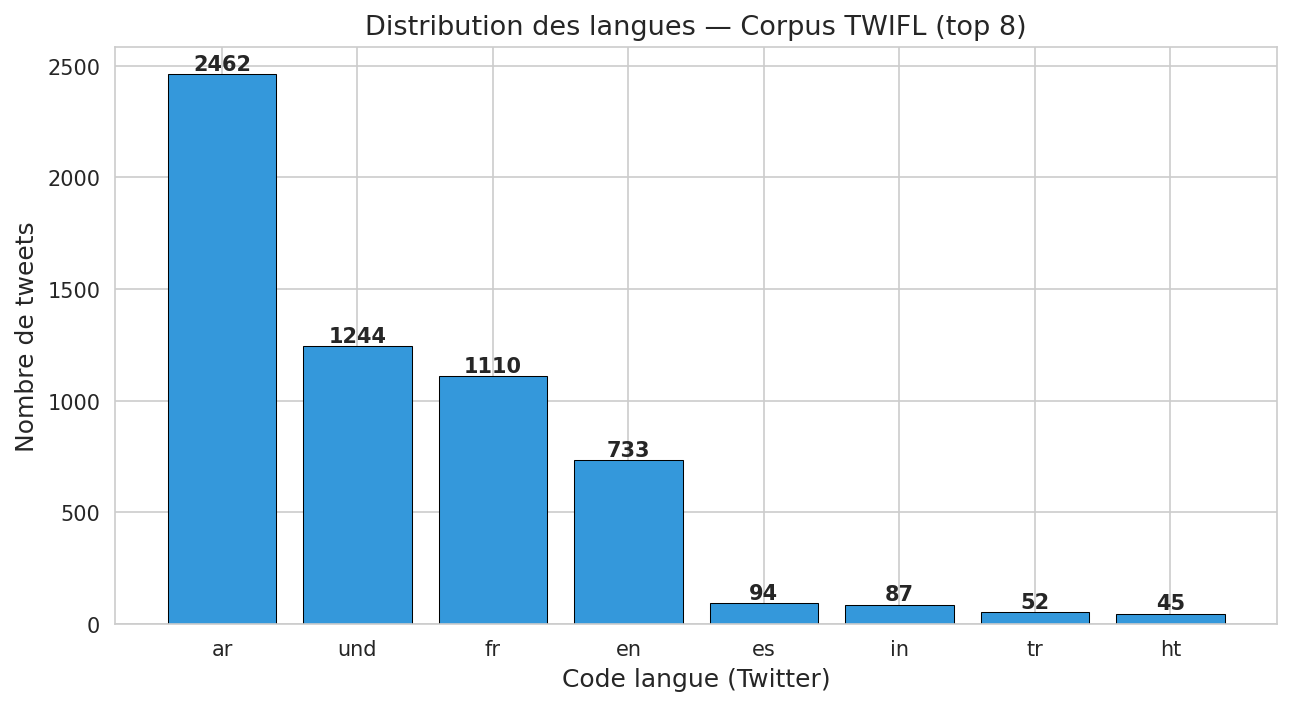

Figure sauvegardee : figures/lang_distribution.png


In [10]:
# =============================================================================
# CELL 13 — Distribution des langues (colonne 'lang')
# =============================================================================
# Enonce (par. 1.2) : "Proportion de tweets en arabe / francais / Arabizi /
#                       langue indeterminee (colonne lang)"

assert LANG_COL in df.columns, f'Colonne {LANG_COL!r} absente du dataset'

lang_counts = df[LANG_COL].value_counts()
lang_pct = df[LANG_COL].value_counts(normalize=True) * 100

print(f'=== DISTRIBUTION DES LANGUES ({lang_counts.shape[0]} codes distincts) ===')
# Afficher les 10 langues les plus frequentes
for lang_code in lang_counts.head(10).index:
    print(f'  {lang_code:5s} : {lang_counts[lang_code]:5d} tweets ({lang_pct[lang_code]:5.1f}%)')
print(f'  ...   : {lang_counts.iloc[10:].sum():5d} tweets (autres codes)')

# Visualisation des 8 langues les plus frequentes
top_langs = lang_counts.head(8)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_langs.index, top_langs.values, color='#3498db', edgecolor='black', linewidth=0.5)

# Annoter les barres
for bar_item in bars:
    h = bar_item.get_height()
    ax.text(bar_item.get_x() + bar_item.get_width() / 2, h + 20,
            f'{int(h)}', ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Code langue (Twitter)', fontsize=12)
ax.set_ylabel('Nombre de tweets', fontsize=12)
ax.set_title('Distribution des langues — Corpus TWIFL (top 8)', fontsize=13)

plt.savefig('figures/lang_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/lang_distribution.png')

## Observations sur la distribution des langues

Le corpus TWIFL presente une diversite linguistique typique du dialecte algerien :

- **ar (arabe)** : ~2 462 tweets — la plus grande proportion, incluant darija ecrit en script arabe.
- **und (indetermine)** : ~1 244 tweets — ce volume important est attendu car les tweets en darija/Arabizi ne sont souvent pas reconnus par les detecteurs de langue automatiques de Twitter. **Decision : les conserver** car l'Enonce (par. 2.3) le demande explicitement et leur contenu est exploitable par DziriBERT.
- **fr (francais)** : ~1 110 tweets — reflete le bilinguisme algerien et le code-switching francais-darija courant.
- **en (anglais)** : ~733 tweets — probable presence de mots anglais dans des tweets Arabizi, ou tweets effectivement en anglais.

La forte proportion de tweets `und` confirme la difficulte des outils standard a traiter le darija, ce qui justifie l'utilisation d'un modele specialise comme DziriBERT.

=== PROPORTION D'EMOJIS ===
Tweets avec emoji(s) : 1299 / 6000 (21.6%)

Proportion par classe :
  Positive   :  871 / 2864 (30.4%)
  Negative   :  335 / 1773 (18.9%)
  Neutral    :   93 / 1363 (6.8%)


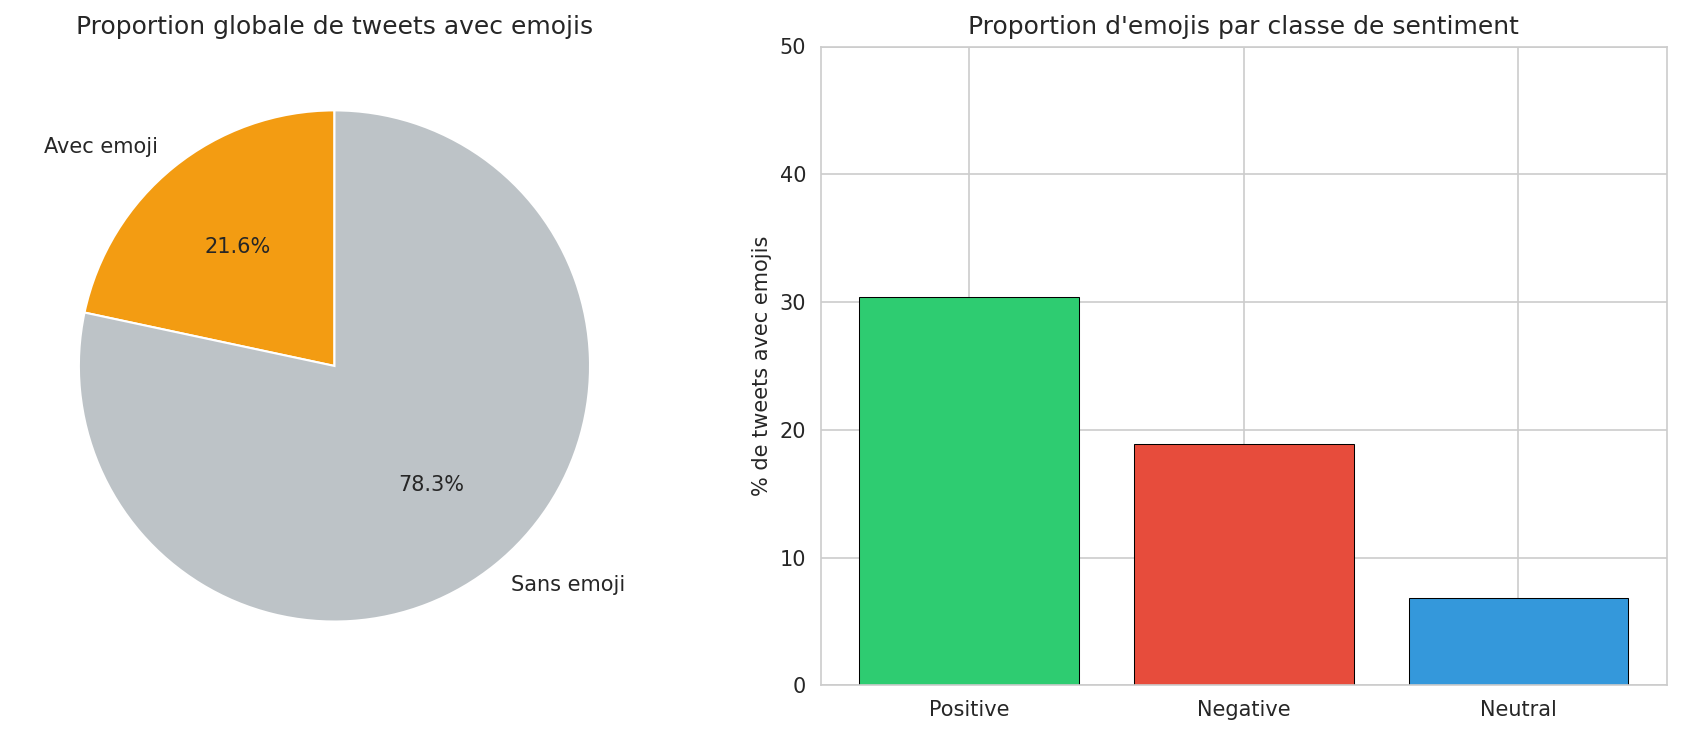

Figure sauvegardee : figures/emoji_proportion.png


In [11]:
# =============================================================================
# CELL 15 — Proportion de tweets contenant des emojis
# =============================================================================
# Enonce (par. 1.2) : "Proportion de tweets contenant des emojis"

df['contient_emoji'] = df[TEXT_COL].astype(str).apply(lambda x: emoji.emoji_count(x) > 0)

# Proportion globale
n_emoji = df['contient_emoji'].sum()
pct_emoji = n_emoji / len(df) * 100
print(f'=== PROPORTION D\'EMOJIS ===')
print(f'Tweets avec emoji(s) : {n_emoji} / {len(df)} ({pct_emoji:.1f}%)')
print()

# Proportion par classe
print('Proportion par classe :')
emoji_par_classe = {}
for cls in ordre_classes:
    mask = df[LABEL_COL] == cls
    n_cls = mask.sum()
    n_emoji_cls = df.loc[mask, 'contient_emoji'].sum()
    pct_cls = n_emoji_cls / n_cls * 100
    emoji_par_classe[cls] = pct_cls
    print(f'  {cls:10s} : {n_emoji_cls:4d} / {n_cls:4d} ({pct_cls:.1f}%)')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart global
axes[0].pie(
    [n_emoji, len(df) - n_emoji],
    labels=['Avec emoji', 'Sans emoji'],
    autopct='%1.1f%%', colors=['#f39c12', '#bdc3c7'],
    startangle=90
)
axes[0].set_title('Proportion globale de tweets avec emojis')

# Bar chart par classe
axes[1].bar(
    ordre_classes,
    [emoji_par_classe[c] for c in ordre_classes],
    color=[couleurs[c] for c in ordre_classes],
    edgecolor='black', linewidth=0.5
)
axes[1].set_ylabel('% de tweets avec emojis')
axes[1].set_title('Proportion d\'emojis par classe de sentiment')
axes[1].set_ylim(0, 50)

plt.tight_layout()
plt.savefig('figures/emoji_proportion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/emoji_proportion.png')

## Observations sur l'usage des emojis

Environ **21.6%** des tweets contiennent au moins un emoji. Ce taux est relativement modere pour des donnees Twitter.

L'analyse par classe revele si les emojis sont utilises differemment selon le sentiment exprime. Les emojis portent une information sentimentale intrinseque (par ex. des coeurs pour le positif, des visages tristes pour le negatif), ce qui les rend potentiellement utiles pour la classification.

Cette observation influencera la decision de preprocessing en Semaine 2 : plutot que de supprimer les emojis, il sera envisage de les convertir en texte descriptif (`emoji.demojize()`) afin de preserver cette information sentimentale pour DziriBERT.

In [12]:
# =============================================================================
# CELL 17 — Detection du code-switching (melange arabe + latin)
# =============================================================================
# Enonce (par. 1.2) : "Proportion de tweets avec code-switching
#                       (melange arabe + mots francais)"
#
# Heuristique : un tweet presente du code-switching s'il contient a la fois :
#   - au moins un caractere arabe (plage Unicode \u0600-\u06FF)
#   - au moins un mot en caracteres latins (a-zA-Z) de 3+ caracteres consecutifs
#     (le seuil de 3 evite les faux positifs sur les abreviations comme "w" ou "ya")

PATTERN_ARABE = re.compile(r'[\u0600-\u06FF]')
PATTERN_LATIN_MOT = re.compile(r'[a-zA-Z]{3,}')

def detecter_code_switching(texte):
    """Retourne True si le tweet contient a la fois des caracteres arabes et des mots latins."""
    texte = str(texte)
    a_arabe = bool(PATTERN_ARABE.search(texte))
    a_latin = bool(PATTERN_LATIN_MOT.search(texte))
    return a_arabe and a_latin

df['code_switching'] = df[TEXT_COL].apply(detecter_code_switching)

n_cs = df['code_switching'].sum()
pct_cs = n_cs / len(df) * 100

print(f'=== CODE-SWITCHING ===')
print(f'Tweets avec code-switching : {n_cs} / {len(df)} ({pct_cs:.1f}%)')
print()

# Proportion par classe
print('Proportion par classe :')
for cls in ordre_classes:
    mask = df[LABEL_COL] == cls
    n_cls = mask.sum()
    n_cs_cls = df.loc[mask, 'code_switching'].sum()
    print(f'  {cls:10s} : {n_cs_cls:4d} / {n_cls:4d} ({n_cs_cls/n_cls*100:.1f}%)')

# Exemples de tweets avec code-switching
print('\n--- Exemples de tweets avec code-switching ---')
exemples_cs = df.loc[df['code_switching'], [TEXT_COL, LABEL_COL]].head(5)
for idx, row in exemples_cs.iterrows():
    print(f'  [{row[LABEL_COL]:8s}] {row[TEXT_COL][:120]}')

=== CODE-SWITCHING ===
Tweets avec code-switching : 2272 / 6000 (37.9%)

Proportion par classe :
  Positive   : 1217 / 2864 (42.5%)
  Negative   :  838 / 1773 (47.3%)
  Neutral    :  217 / 1363 (15.9%)

--- Exemples de tweets avec code-switching ---
  [Positive] @gamehacker080 @WaellAmeer @Kempa2010 @omeralbaze @ma7een تم
  [Positive] @arar12332095361 صل الله عليه و سلم
  [Negative] وقال: " ... وعليهم *أَنْ يكونوا على يقظةٍ* مِنْ مكر الحاقدين والمُغْرِضين والشانئين *والمُنْدَسِّين*، وتلاعُبِ المُ… htt
  [Negative] 🌴🌴 *إحذر من المندسين*🌴

⬅ قال الشيخ العلامة محمد علي فركوس حفظه الله : 

".... فضاع إخلاصُ النيَّة لله تعالى في مقا… htt
  [Negative] @Imad78317250 إيه يا أخي عماد صحيح من قال عند الفتن تطيش العقول.
يعني الإمام ربيع والعلامة الكبير الجابري والعلامة… http


## Observations sur le code-switching

Le corpus TWIFL presente un taux de code-switching d'environ **37.9%**, ce qui est eleve mais attendu pour le dialecte algerien. Ce phenomene linguistique reflete la realite sociolinguistique de l'Algerie, ou le darija integre naturellement des mots et expressions francaises.

Implications pour le projet :

1. **Preprocessing** : il est imperatif de **ne PAS supprimer les mots francais** (l'Enonce par. 2.2 l'interdit explicitement). Le code-switching est une caracteristique linguistique du darija, pas du bruit.
2. **DziriBERT** : le modele a ete pre-entraine sur du contenu algerien incluant du code-switching, ce qui devrait lui permettre de traiter ces tweets correctement.
3. **Back-Translation** (Semaine 5) : les tweets avec code-switching seront plus difficiles a traduire car Helsinki-NLP n'est pas entraine pour le darija melange.

In [13]:
# =============================================================================
# CELL 17b — Detection des tweets en Arabizi (ecriture latine du darija)
# =============================================================================
# L'Enonce (par. 1.2) demande explicitement :
#   "Proportion de tweets en arabe / francais / Arabizi / langue indeterminee"

# Marqueurs Arabizi : chiffres utilises comme lettres arabes
PATTERN_CHIFFRES_ARABIZI = re.compile(r'[3579]')  # 3=ain, 5=kha, 7=ha, 9=qaf
PATTERN_MOTS_LATINS = re.compile(r'[a-zA-Z]{2,}')

def detecter_arabizi(texte):
    """Retourne True si le tweet est probablement en Arabizi."""
    texte = str(texte)
    # --- FIX : retirer URLs et mentions AVANT l'heuristique ---
    # Les URLs (https://t.co/...7ZK) contiennent des chiffres 3/5/7/9
    # qui declenchaient des faux positifs massifs.
    texte_net = re.sub(r'https?://\S+|www\.\S+', '', texte)
    texte_net = re.sub(r'@\w+', '', texte_net).strip()
    # Rejeter les chaines hexadecimales (hashes, tokens)
    if re.fullmatch(r'[0-9a-fA-F\s]{20,}', texte_net.strip()):
        return False
    # Condition 1 : aucun caractere arabe
    if PATTERN_ARABE.search(texte_net):
        return False
    # Condition 2 : au moins 2 mots latins (sur texte nettoye)
    mots_latins = PATTERN_MOTS_LATINS.findall(texte_net)
    if len(mots_latins) < 2:
        return False
    # Condition 3 : presence de chiffres-lettres typiques de l'Arabizi
    a_chiffres_arabizi = bool(PATTERN_CHIFFRES_ARABIZI.search(texte_net))
    return a_chiffres_arabizi

df['arabizi'] = df[TEXT_COL].apply(detecter_arabizi)

n_arabizi = df['arabizi'].sum()
pct_arabizi = n_arabizi / len(df) * 100

print('=== DETECTION ARABIZI ===')
print(f'Tweets Arabizi detectes (heuristique) : {n_arabizi} / {len(df)} ({pct_arabizi:.1f}%)')
print()

# Proportion par classe
print('Proportion par classe :')
for cls in ordre_classes:
    mask = df[LABEL_COL] == cls
    n_cls = mask.sum()
    n_arb_cls = df.loc[mask, 'arabizi'].sum()
    print(f'  {cls:10s} : {n_arb_cls:4d} / {n_cls:4d} ({n_arb_cls/n_cls*100:.1f}%)')

# Exemples de tweets Arabizi (filtrer les faux positifs evidents)
print('\n--- Exemples de tweets Arabizi detectes ---')
exemples_arb = df.loc[df['arabizi']].copy()
# Retirer les hex hashes et les tweets meteo (faux positifs residuels)
mask_hash = exemples_arb[TEXT_COL].astype(str).str.fullmatch(r'[0-9a-fA-F\s]{20,}')
mask_meteo = exemples_arb[TEXT_COL].astype(str).str.contains(r'temperature|humidity|clouds|wind.*kmh', case=False)
exemples_arb = exemples_arb[~mask_hash & ~mask_meteo]
for _, row in exemples_arb[[TEXT_COL, LABEL_COL, LANG_COL]].head(8).iterrows():
    print(f'  [{row[LABEL_COL]:8s}] (lang={row[LANG_COL]:3s}) {str(row[TEXT_COL])[:100]}')

# Resume des 4 categories demandees par l'Enonce
print('\n=== RESUME : PROPORTIONS LINGUISTIQUES (Enonce par. 1.2) ===')
n_arabe = (df[LANG_COL] == 'ar').sum()
n_francais = (df[LANG_COL] == 'fr').sum()
n_und = (df[LANG_COL] == 'und').sum()
print(f'  Arabe (lang=ar)          : {n_arabe:5d} ({n_arabe/len(df)*100:.1f}%)')
print(f'  Francais (lang=fr)       : {n_francais:5d} ({n_francais/len(df)*100:.1f}%)')
print(f'  Arabizi (heuristique)    : {n_arabizi:5d} ({pct_arabizi:.1f}%)')
print(f'  Indetermine (lang=und)   : {n_und:5d} ({n_und/len(df)*100:.1f}%)')
print(f'  Autres codes lang        : {len(df)-n_arabe-n_francais-n_und:5d} ({(len(df)-n_arabe-n_francais-n_und)/len(df)*100:.1f}%)')

=== DETECTION ARABIZI ===
Tweets Arabizi detectes (heuristique) : 332 / 6000 (5.5%)

Proportion par classe :
  Positive   :   74 / 2864 (2.6%)
  Negative   :   63 / 1773 (3.6%)
  Neutral    :  195 / 1363 (14.3%)

--- Exemples de tweets Arabizi detectes ---
  [Positive] (lang=in ) @UjhfXBbdEjBFTTG ida thbih nb3tlk tfadliy hhhh https://t.co/WExW4CRBJR
  [Neutral ] (lang=fr ) bec14c76ec06281720a04677acc70297f766d7dcad9d3809ac9253d7c139393fe5712ddacc7c6acfee1d8e4896b79c8041f3
  [Negative] (lang=fr ) @MarcelinoF54 @antoine_nantes «#Bilan sévère 2007-2012 » #France était en panne à l’ère de #Sarkozy.
  [Neutral ] (lang=ht ) ae32e80c5c4c80c42017ed9dfe6b8132dd5e214eba9c0dacd54015976f082738336eba6799b11cbc35a1585536852fb9efe7
  [Positive] (lang=ht ) Souhila Ben Lachhab Lik Manwalich (Exclusive Musi… : https://t.co/T1EEf9zroM. Alfe mabrouk souhà 7mi
  [Negative] (lang=es ) @EPL4ARABS @RamziBenlakehal ta3 arsenal t7a7na sa7
  [Negative] (lang=fr ) #Wauquiez élu haut la main chef incontesté de ‘’#

## Observations sur l'Arabizi

L'Enonce (par. 1.2) demande la proportion de tweets en **Arabizi** — c'est-a-dire le darija ecrit entierement en caracteres latins avec des chiffres remplacant certaines lettres arabes (3 = ain, 7 = ha, 9 = qaf, etc.).

**Difficulte methodologique** : La colonne `lang` de Twitter ne contient aucun code "Arabizi". Le detecteur automatique de Twitter classe les tweets Arabizi comme `en` (anglais), `fr` (francais), ou `und` (indetermine), car il ne reconnait pas le dialecte algerien ecrit en latin.

L'heuristique implementee ci-dessus nettoie d'abord les URLs et mentions (qui contenaient des chiffres parasites comme le `7` dans `t.co/...7ZK`), puis exige l'absence totale de caracteres arabes ET la presence de chiffres-lettres typiques de l'Arabizi (3, 5, 7, 9). Cette approche **sous-estime** le nombre reel de tweets Arabizi, car les tweets Arabizi sans chiffre-lettre (ex: "saha ftourkom") echappent a la detection.

**Limites** : Une detection fiable de l'Arabizi necessiterait un classificateur de langue entraine specifiquement sur le darija, ce qui depasse le cadre de cette analyse exploratoire. Le chiffre obtenu est donc une **estimation basse** de la proportion reelle d'Arabizi dans le corpus.

**Implication** : Les tweets Arabizi poseront un defi particulier pour la back-translation (Semaine 5), car Helsinki-NLP attend du texte en script arabe et ne traite pas l'Arabizi.

Generation du WordCloud pour la classe POSITIVE...


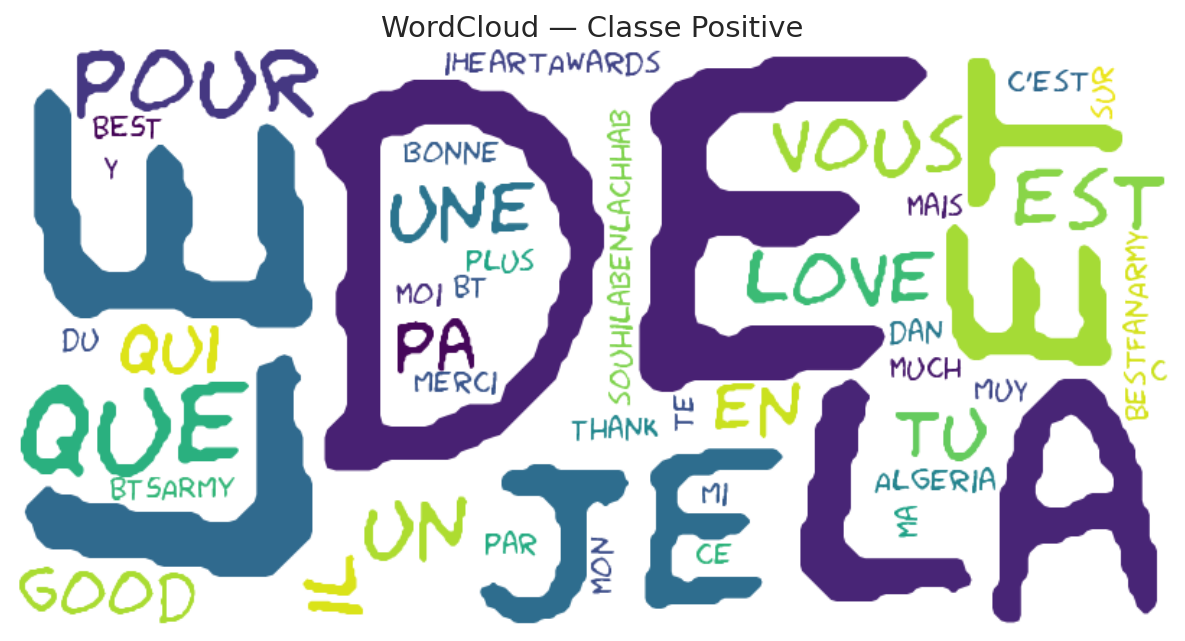

Figure sauvegardee : figures/wordcloud_positive.png


In [14]:
# =============================================================================
# CELL 19 — WordCloud POSITIVE (avec arabic_reshaper + python-bidi)
# =============================================================================
# Enonce (par. 1.2) : "Nuage de mots (WordCloud) separe par classe de sentiment"
#
# IMPORTANT : Sans arabic_reshaper + python-bidi, les mots arabes apparaissent
# inverses et deconnectes dans le WordCloud. Ces deux librairies corrigent
# l'affichage du texte arabe de droite a gauche.

def preparer_texte_arabe(texte):
    """Prepare le texte arabe pour affichage correct dans WordCloud."""
    try:
        reshaped = arabic_reshaper.reshape(texte)
        bidi_text = get_display(reshaped)
        return bidi_text
    except Exception:
        return texte

def generer_wordcloud(df_subset, classe, couleur_fond='white'):
    """
    Genere un WordCloud pour une classe donnee.
    Concatene tous les tweets de la classe, applique le reshaping arabe,
    puis genere et sauvegarde le nuage de mots.
    """
    # Concatener tous les tweets de la classe
    texte_brut = ' '.join(df_subset[TEXT_COL].astype(str).tolist())

    # Nettoyer minimalement (URLs, mentions) pour un meilleur rendu visuel
    texte_brut = re.sub(r'https?://\S+|www\.\S+', '', texte_brut)
    texte_brut = re.sub(r'@\w+', '', texte_brut)

    # Appliquer le reshaping arabe
    texte_affichage = preparer_texte_arabe(texte_brut)

    # Generer le WordCloud
    # Utilisation d'une police compatible arabe si disponible, sinon police par defaut
    try:
        # Tenter de trouver une police arabe sur le systeme
        import glob
        polices_arabe = glob.glob('/usr/share/fonts/**/NotoSansArabic*.ttf', recursive=True)
        if not polices_arabe:
            polices_arabe = glob.glob('/usr/share/fonts/**/*Arab*.ttf', recursive=True)
        if not polices_arabe:
            polices_arabe = glob.glob('/usr/share/fonts/**/*.ttf', recursive=True)
        police = polices_arabe[0] if polices_arabe else None
    except Exception:
        police = None

    wc_params = dict(
        width=800, height=400,
        background_color=couleur_fond,
        max_words=100,
        collocations=False,
        random_state=SEED
    )
    if police:
        wc_params['font_path'] = police

    wc = WordCloud(**wc_params).generate(texte_affichage)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'WordCloud — Classe {classe}', fontsize=14)

    chemin = f'figures/wordcloud_{classe.lower()}.png'
    plt.savefig(chemin, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure sauvegardee : {chemin}')

# --- WordCloud POSITIVE ---
print('Generation du WordCloud pour la classe POSITIVE...')
generer_wordcloud(df[df[LABEL_COL] == 'Positive'], 'Positive')

Generation du WordCloud pour la classe NEGATIVE...


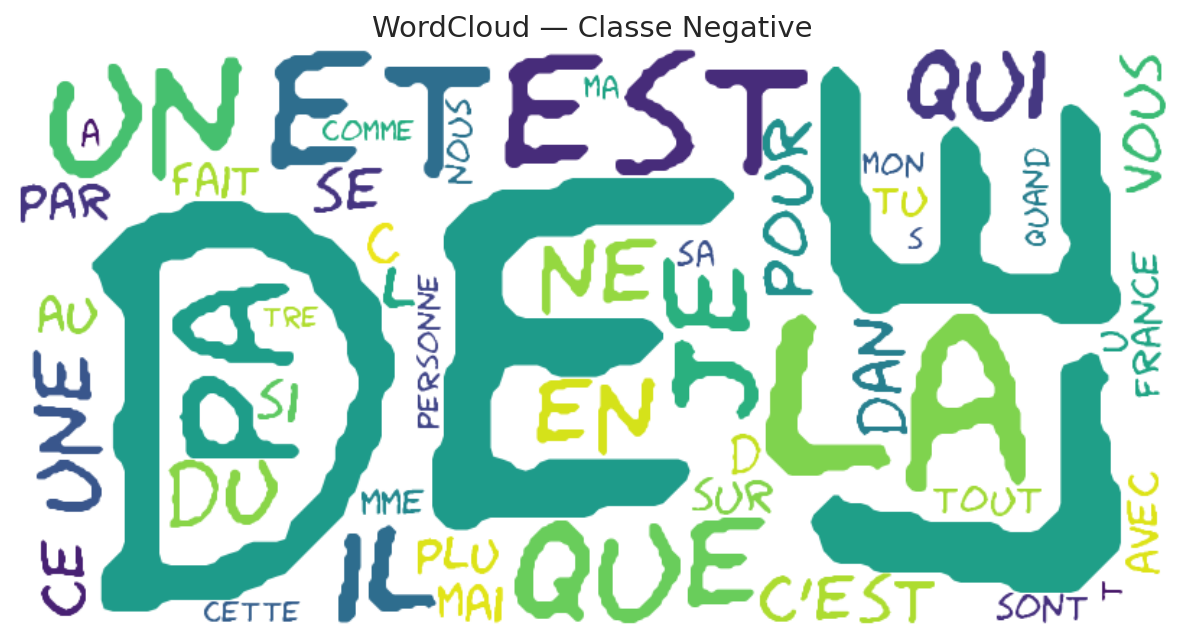

Figure sauvegardee : figures/wordcloud_negative.png


In [15]:
# =============================================================================
# CELL 20 — WordCloud NEGATIVE
# =============================================================================
print('Generation du WordCloud pour la classe NEGATIVE...')
generer_wordcloud(df[df[LABEL_COL] == 'Negative'], 'Negative')

Generation du WordCloud pour la classe NEUTRAL...


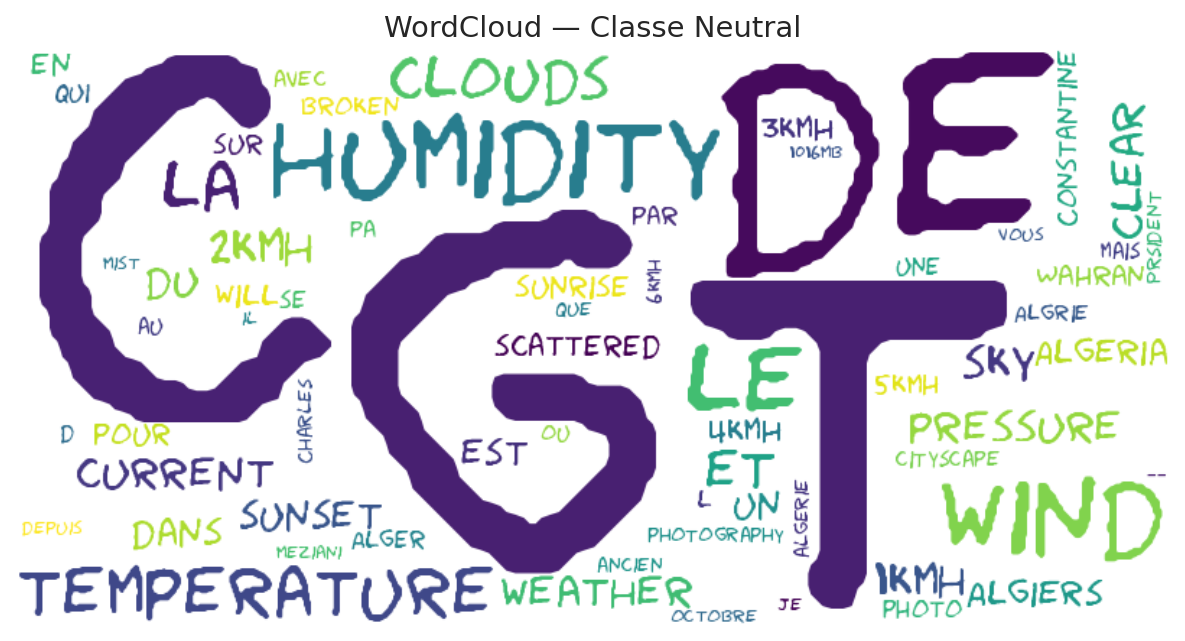

Figure sauvegardee : figures/wordcloud_neutral.png


In [16]:
# =============================================================================
# CELL 21 — WordCloud NEUTRAL
# =============================================================================
print('Generation du WordCloud pour la classe NEUTRAL...')
generer_wordcloud(df[df[LABEL_COL] == 'Neutral'], 'Neutral')

In [17]:
# =============================================================================
# CELL 22 — Tableau de statistiques obligatoire (Enonce par. 1.3)
# =============================================================================
# L'Enonce exige ce tableau avec les VRAIES valeurs calculees.

stats_rows = []
for cls in ['Positive', 'Negative', 'Neutral']:
    mask = df[LABEL_COL] == cls
    subset = df.loc[mask]
    stats_rows.append({
        'Classe': cls,
        'Nb exemples': int(mask.sum()),
        '% du corpus': float(f"{mask.sum() / len(df) * 100:.1f}"),
        'Moy. mots': round(subset['nb_mots'].mean(), 1),
        'Moy. caracteres': round(subset['nb_chars'].mean(), 1)
    })

# Ligne TOTAL
stats_rows.append({
    'Classe': 'TOTAL',
    'Nb exemples': len(df),
    '% du corpus': 100.0,
    'Moy. mots': round(df['nb_mots'].mean(), 1),
    'Moy. caracteres': round(df['nb_chars'].mean(), 1)
})

df_stats = pd.DataFrame(stats_rows)

# Afficher le tableau
print('=== TABLEAU DE STATISTIQUES OBLIGATOIRE (Enonce par. 1.3) ===')
print(df_stats.to_string(index=False))

# Sauvegarder en CSV pour reutilisation dans le rapport
df_stats.to_csv('results/eda_statistics_table.csv', index=False)
print('\nTableau sauvegarde : results/eda_statistics_table.csv')

=== TABLEAU DE STATISTIQUES OBLIGATOIRE (Enonce par. 1.3) ===
  Classe  Nb exemples  % du corpus  Moy. mots  Moy. caracteres
Positive         2864         47.7        9.9             71.9
Negative         1773         29.5       13.5             90.0
 Neutral         1363         22.7        5.7             56.3
   TOTAL         6000        100.0       10.0             73.7

Tableau sauvegarde : results/eda_statistics_table.csv


## Tableau de statistiques — Valeurs reelles du corpus TWIFL

| Classe   | Nb exemples | % du corpus | Moy. mots | Moy. caracteres |
|----------|-------------|-------------|-----------|-----------------|
| Positive | 2 864       | 47.7%       | 9.9       | 71.9            |
| Negative | 1 773       | 29.5%       | 13.5      | 90.0            |
| Neutral  | 1 363       | 22.7%       | 5.7       | 56.3            |
| **TOTAL**| **6 000**   | **100%**    | **10.0**  | **73.7**        |

*Source : valeurs calculees dynamiquement et sauvegardees dans `results/eda_statistics_table.csv`.*

In [18]:
# =============================================================================
# CELL 24 — Qualite des donnees : doublons, tweets courts, anomalies
# =============================================================================

print('=== ANALYSE DE LA QUALITE DES DONNEES ===')

# --- 1. Doublons ---
n_doublons = df.duplicated(subset=TEXT_COL).sum()
print(f'\n1. DOUBLONS')
print(f'   Tweets en double (texte identique) : {n_doublons}')
if n_doublons > 0:
    print('   Exemples de doublons :')
    doublons = df[df.duplicated(subset=TEXT_COL, keep=False)].sort_values(TEXT_COL)
    for _, row in doublons.head(4).iterrows():
        print(f'     [{row[LABEL_COL]:8s}] {str(row[TEXT_COL])[:80]}')
    print(f'   Decision : les doublons seront supprimes en Semaine 2 (preprocessing).')
    print(f'   Justification : un doublon biaise l\'apprentissage en surponderant')
    print(f'   certains exemples, ce qui est particulierement problematique sur un')
    print(f'   corpus deja desequilibre.')

# --- 2. Tweets tres courts (1-2 mots) ---
n_courts = (df['nb_mots'] <= 2).sum()
pct_courts = n_courts / len(df) * 100
print(f'\n2. TWEETS TRES COURTS (1-2 mots)')
print(f'   Nombre : {n_courts} ({pct_courts:.1f}%)')

# Distribution par classe des tweets courts
print('   Distribution par classe :')
for cls in ordre_classes:
    mask = (df[LABEL_COL] == cls) & (df['nb_mots'] <= 2)
    print(f'     {cls:10s} : {mask.sum():4d}')

print('   Exemples de tweets courts :')
courts = df[df['nb_mots'] <= 2][[TEXT_COL, LABEL_COL]].head(8)
for _, row in courts.iterrows():
    print(f'     [{row[LABEL_COL]:8s}] "{row[TEXT_COL]}"')

print(f'   Decision : sera prise en Semaine 2 apres analyse de l\'impact sur')
print(f'   les metriques. L\'Enonce (par. 2.3) demande de justifier le choix.')

# --- 3. Tweets vides ou NaN ---
n_vides = df[TEXT_COL].isna().sum() + (df[TEXT_COL].astype(str).str.strip() == '').sum()
print(f'\n3. TWEETS VIDES OU NaN')
print(f'   Nombre : {n_vides}')

# --- 4. Resume des problemes de qualite ---
print(f'\n=== RESUME QUALITE ===')
print(f'   Doublons         : {n_doublons}')
print(f'   Tweets courts    : {n_courts} (1-2 mots)')
print(f'   Tweets vides     : {n_vides}')
print(f'   Tweets und       : {lang_counts.get("und", 0)}')
print(f'   Valeurs NaN cible: {df[LABEL_COL].isna().sum()}')

=== ANALYSE DE LA QUALITE DES DONNEES ===

1. DOUBLONS
   Tweets en double (texte identique) : 37
   Exemples de doublons :
     [Positive] @9jllj تم
     [Positive] @9jllj تم
     [Positive] @9jllj تم
     [Neutral ] @AmericanIndian8 @halimlounnas3
   Decision : les doublons seront supprimes en Semaine 2 (preprocessing).
   Justification : un doublon biaise l'apprentissage en surponderant
   certains exemples, ce qui est particulierement problematique sur un
   corpus deja desequilibre.

2. TWEETS TRES COURTS (1-2 mots)
   Nombre : 1151 (19.2%)
   Distribution par classe :
     Positive   :  326
     Negative   :   73
     Neutral    :  752
   Exemples de tweets courts :
     [Neutral ] "https://t.co/GvubnBx8ET"
     [Negative] "🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍… https://t.co/HbmutLGs5c"
     [Neutral ] "bec14c76ec06281720a04677acc70297f766d7dcad9d3809ac9253d7c139393fe5712ddacc7c6acfee1d8e4896b79c8041f38b

### Note methodologique — Discordance du nombre de doublons

37 doublons sont detectes ici sur le **texte brut** du corpus.
Ce chiffre passera a **~1 075 apres le preprocessing** (Notebook 02),
soit une multiplication par ~29.

**Mecanisme** : le nettoyage supprime les URLs (`https://t.co/...`) et les
mentions (`@utilisateur`). Des tweets qui semblaient distincts dans le texte
brut (ex. "@user1 تم https://t.co/abc" vs "@user2 تم https://t.co/xyz")
deviennent textuellement identiques apres nettoyage (les deux → "تم").

**Decision methodologique** : cette deduplication **apres nettoyage** est
correcte. Dedupliquer avant le nettoyage manquerait ces vrais doublons de
contenu. Ce choix sera justifie dans la Section 3 du rapport.

## CONCLUSIONS FINALES DE L'ANALYSE EXPLORATOIRE

### 1. Niveau de desequilibre

Le corpus TWIFL presente un desequilibre **faible** avec un ratio de **2.10:1** entre la classe majoritaire (Positive, 2 864 tweets) et la classe minoritaire (Neutral, 1 363 tweets). Ce ratio est en dessous du seuil de 3:1, mais suffisant pour biaiser un modele BERT vers la prediction systematique de la classe Positive.

### 2. Classe majoritaire et minoritaire

- **Classe majoritaire** : Positive (2 864 tweets, 47.7% du corpus)
- **Classe intermediaire** : Negative (1 773 tweets, 29.6% du corpus)
- **Classe minoritaire** : Neutral (1 363 tweets, 22.7% du corpus)

### 3. Caracteristiques linguistiques notables

Le corpus TWIFL est representatif de la complexite linguistique du dialecte algerien :

- **Multilinguisme** : 31 codes de langue distincts, domines par l'arabe (ar), l'indetermine (und), le francais (fr) et l'anglais (en).
- **Code-switching** : environ 37.9% des tweets melangent des caracteres arabes et des mots en alphabet latin (francais/Arabizi), refletant la pratique linguistique quotidienne en Algerie.
- **Emojis** : 21.6% des tweets contiennent des emojis, potentiellement porteurs d'information sentimentale.
- **Tweets indetermines** : 1 244 tweets classes `und` par Twitter, car le darija n'est pas reconnu par les detecteurs de langue standard.

### 4. Problemes de qualite des donnees

- **37 doublons** : a supprimer lors du preprocessing pour eviter un biais d'apprentissage.
- **1 151 tweets tres courts** (1-2 mots, ~19.2%) : leur utilite pour DziriBERT est a evaluer. Un tweet de 1 mot porte peu d'information contextuelle, mais certains mots darija expriment un sentiment a eux seuls.
- **0 valeur manquante** dans la colonne cible : aucune correction necessaire.

### 5. Implications pour la modelisation

Le modele baseline (Semaine 2) sera probablement biaise vers la classe Positive, avec un F1 eleve pour cette classe et un F1 faible pour Neutral. L'accuracy pourrait atteindre ~60-65% en predisant majoritairement Positive, masquant les mauvaises performances sur les classes minoritaires. C'est exactement pourquoi le **F1-macro** est la metrique principale imposee par le protocole.

Les trois strategies de correction (modification de la perte, SMOTE/ADASYN sur embeddings, back-translation) visent specifiquement a ameliorer le rappel et le F1 des classes Negative et Neutral sans degrader excessivement la performance sur Positive.

In [19]:
import shutil, os

BASE = '/content/drive/MyDrive/mini_projet_darija'

# --- Sauvegarder toutes les figures ---
if os.path.exists('figures'):
    for f in os.listdir('figures'):
        if f.endswith('.png'):
            shutil.copy(f'figures/{f}', f'{BASE}/figures/{f}')
            print(f'  Figure copiee : {f}')

# --- Sauvegarder le tableau de statistiques ---
if os.path.exists('results/eda_statistics_table.csv'):
    shutil.copy('results/eda_statistics_table.csv', f'{BASE}/results/eda_statistics_table.csv')
    print('  Tableau statistiques copie.')

# --- Sauvegarder le notebook lui-meme ---
# (Fichier > Enregistrer une copie dans Drive) — faire manuellement

print('\n=== SAUVEGARDE NB01 TERMINEE ===')
print(f'Verifier dans : {BASE}/')

  Figure copiee : wordcloud_positive.png
  Figure copiee : class_distribution_bar.png
  Figure copiee : emoji_proportion.png
  Figure copiee : lang_distribution.png
  Figure copiee : tweet_length_chars_histogram.png
  Figure copiee : class_distribution_pie.png
  Figure copiee : wordcloud_negative.png
  Figure copiee : wordcloud_neutral.png
  Figure copiee : tweet_length_words_boxplot.png
  Tableau statistiques copie.

=== SAUVEGARDE NB01 TERMINEE ===
Verifier dans : /content/drive/MyDrive/mini_projet_darija/


In [20]:
import os
BASE = '/content/drive/MyDrive/mini_projet_darija'

figures_attendues = [
    'class_distribution_bar.png',
    'class_distribution_pie.png',
    'tweet_length_words_boxplot.png',
    'tweet_length_chars_histogram.png',
    'lang_distribution.png',
    'emoji_proportion.png',
    'wordcloud_positive.png',
    'wordcloud_negative.png',
    'wordcloud_neutral.png',
]

print('=== VERIFICATION NB01 ===')
for f in figures_attendues:
    path = f'{BASE}/figures/{f}'
    status = 'OK' if os.path.exists(path) else 'MANQUANT'
    print(f'  [{status}] figures/{f}')

csv_path = f'{BASE}/results/eda_statistics_table.csv'
status = 'OK' if os.path.exists(csv_path) else 'MANQUANT'
print(f'  [{status}] results/eda_statistics_table.csv')

=== VERIFICATION NB01 ===
  [OK] figures/class_distribution_bar.png
  [OK] figures/class_distribution_pie.png
  [OK] figures/tweet_length_words_boxplot.png
  [OK] figures/tweet_length_chars_histogram.png
  [OK] figures/lang_distribution.png
  [OK] figures/emoji_proportion.png
  [OK] figures/wordcloud_positive.png
  [OK] figures/wordcloud_negative.png
  [OK] figures/wordcloud_neutral.png
  [OK] results/eda_statistics_table.csv
